# Train A Phase-Equivariant CNN On The Signal Dataset

This notebook mirrors `train_cnn.ipynb`, but replaces the front end with complex-valued convolution blocks that are equivariant to global phase rotation. The transition into the real-valued CNN uses globally phase-invariant learned features: magnitude and local relative phase. That is a better fit than pure magnitude pooling for PSK-heavy modulation sets.

Design choices used here:
- bias-free complex convolutions in the early stem,
- radial nonlinearities of the form `g(|z|) z`,
- average pooling in the complex stem so the linear equivariance is preserved,
- a phase-invariant transition using `|z|` and `z[n] conj(z[n-1])`,
- stronger optimization than the baseline: AdamW, label smoothing, cosine LR decay, and nuisance augmentation during training.

On the frequency-offset question: this stem is not exactly frequency-offset equivariant, but small convolution windows can still learn locally stable patterns under slow phase ramps. The relative-phase transition also makes the residual frequency-offset nuisance simpler than raw absolute phase.

In [1]:
from pathlib import Path
import math
import os
import platform
import subprocess
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ModuleNotFoundError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")
torch.manual_seed(0)
np.random.seed(0)

In [2]:
DATASET_PATH = Path("signals_dataset.h5")
CHECKPOINT_PATH = Path("phase_equivariant_cnn_signal_classifier.pt")

BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

MAX_RANDOM_PHASE = math.pi
MAX_RANDOM_FREQ_RAMP = 0.06
MAX_TIME_SHIFT = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"
num_workers = min(8, os.cpu_count() or 1)
pin_memory = use_cuda
persistent_workers = num_workers > 0

if use_cuda:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Workers: {num_workers}, pin_memory={pin_memory}")

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH.resolve()}")

Python: 3.12.3
Torch: 2.10.0+cu128
Device: cuda
CUDA available: True
Workers: 8, pin_memory=True


In [3]:
def query_nvidia_smi():
    cmd = [
        "nvidia-smi",
        "--query-gpu=index,name,driver_version,memory.total,memory.used,utilization.gpu,utilization.memory,temperature.gpu,power.draw",
        "--format=csv,noheader,nounits",
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
    except (FileNotFoundError, subprocess.CalledProcessError) as exc:
        return f"nvidia-smi unavailable: {exc}"
    return result.stdout.strip()

print(query_nvidia_smi())

0, NVIDIA GeForce RTX 5090, 590.48.01, 32607, 3475, 7, 6, 38, 42.69


In [4]:
with h5py.File(DATASET_PATH, "r") as h5_file:
    signals = h5_file["signals"][:].astype(np.float32)
    labels = h5_file["labels"][:].astype(np.int64)
    class_names = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in h5_file.attrs["class_names"]]
    snr_values = h5_file["metadata"]["SNR"][:].astype(np.float32)
    freq_offsets = h5_file["metadata"]["frequency_offset"][:].astype(np.float32)

# Normalize each example by RMS so the model focuses on structure, not overall scale.
rms = np.sqrt(np.mean(signals ** 2, axis=(1, 2), keepdims=True) + 1e-8)
signals = signals / rms

print("signals shape:", signals.shape)
print("labels shape:", labels.shape)
print("classes:", class_names)
print(f"SNR range: {snr_values.min():.1f} to {snr_values.max():.1f} dB")
print(f"Frequency offset range: {freq_offsets.min():.1f} to {freq_offsets.max():.1f} Hz")

signals shape: (10000, 2, 1024)
labels shape: (10000,)
classes: ['16QAM', '64QAM', '8PSK', 'BPSK', 'PAM4', 'QPSK']
SNR range: 0.0 to 30.0 dB
Frequency offset range: -999.9 to 1000.0 Hz


In [5]:
def stratify_or_none(y: np.ndarray):
    _, counts = np.unique(y, return_counts=True)
    return y if np.all(counts >= 2) else None

X_train, X_temp, y_train, y_temp = train_test_split(
    signals,
    labels,
    test_size=0.2,
    random_state=0,
    stratify=stratify_or_none(labels),
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=0,
    stratify=stratify_or_none(y_temp),
)

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)

train: (8000, 2, 1024) (8000,)
val: (1000, 2, 1024) (1000,)
test: (1000, 2, 1024) (1000,)


In [6]:
class IQDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, training: bool):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.training = training
        self.rng = np.random.default_rng(0 if not training else 12345)

    def __len__(self) -> int:
        return len(self.y)

    def _apply_phase_ramp(self, x: torch.Tensor) -> torch.Tensor:
        length = x.shape[-1]
        phase0 = float(self.rng.uniform(-MAX_RANDOM_PHASE, MAX_RANDOM_PHASE))
        omega = float(self.rng.uniform(-MAX_RANDOM_FREQ_RAMP, MAX_RANDOM_FREQ_RAMP))
        n = torch.arange(length, dtype=x.dtype)
        phase = phase0 + omega * n
        cos_phase = torch.cos(phase)
        sin_phase = torch.sin(phase)
        i = x[0] * cos_phase - x[1] * sin_phase
        q = x[0] * sin_phase + x[1] * cos_phase
        return torch.stack((i, q), dim=0)

    def __getitem__(self, idx: int):
        x = self.X[idx].clone()
        y = self.y[idx]

        if self.training:
            x = self._apply_phase_ramp(x)
            shift = int(self.rng.integers(-MAX_TIME_SHIFT, MAX_TIME_SHIFT + 1))
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1)

        return x, y


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool, training: bool) -> DataLoader:
    dataset = IQDataset(X, y, training=training)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
    )


train_loader = make_loader(X_train, y_train, shuffle=True, training=True)
val_loader = make_loader(X_val, y_val, shuffle=False, training=False)
test_loader = make_loader(X_test, y_test, shuffle=False, training=False)


class ComplexConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, padding: int = 0):
        super().__init__()
        self.stride = stride
        self.padding = padding
        self.real_weight = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size))
        self.imag_weight = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size))
        nn.init.kaiming_uniform_(self.real_weight, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.imag_weight, a=math.sqrt(5))

    def forward(self, real: torch.Tensor, imag: torch.Tensor):
        rr = F.conv1d(real, self.real_weight, bias=None, stride=self.stride, padding=self.padding)
        ii = F.conv1d(imag, self.imag_weight, bias=None, stride=self.stride, padding=self.padding)
        ri = F.conv1d(real, self.imag_weight, bias=None, stride=self.stride, padding=self.padding)
        ir = F.conv1d(imag, self.real_weight, bias=None, stride=self.stride, padding=self.padding)
        return rr - ii, ri + ir


class ComplexRadialGate(nn.Module):
    def __init__(self, channels: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.norm = nn.BatchNorm1d(channels)

    def forward(self, real: torch.Tensor, imag: torch.Tensor):
        magnitude = torch.sqrt(real.square() + imag.square() + self.eps)
        gate = torch.sigmoid(self.norm(magnitude))
        return real * gate, imag * gate


class ComplexAvgPool1d(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.pool = nn.AvgPool1d(kernel_size)

    def forward(self, real: torch.Tensor, imag: torch.Tensor):
        return self.pool(real), self.pool(imag)


class ComplexBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, pool: bool):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = ComplexConv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.act1 = ComplexRadialGate(out_channels)
        self.conv2 = ComplexConv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.act2 = ComplexRadialGate(out_channels)
        self.pool = ComplexAvgPool1d(2) if pool else None

    def forward(self, real: torch.Tensor, imag: torch.Tensor):
        real, imag = self.conv1(real, imag)
        real, imag = self.act1(real, imag)
        real, imag = self.conv2(real, imag)
        real, imag = self.act2(real, imag)
        if self.pool is not None:
            real, imag = self.pool(real, imag)
        return real, imag


class InvariantTransition(nn.Module):
    def __init__(self, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, real: torch.Tensor, imag: torch.Tensor) -> torch.Tensor:
        magnitude = torch.sqrt(real.square() + imag.square() + self.eps)

        rel_real = real[:, :, 1:] * real[:, :, :-1] + imag[:, :, 1:] * imag[:, :, :-1]
        rel_imag = imag[:, :, 1:] * real[:, :, :-1] - real[:, :, 1:] * imag[:, :, :-1]
        rel_real = F.pad(rel_real, (1, 0))
        rel_imag = F.pad(rel_imag, (1, 0))

        rel_scale = torch.sqrt(rel_real.square() + rel_imag.square() + self.eps)
        rel_real = rel_real / rel_scale
        rel_imag = rel_imag / rel_scale
        return torch.cat((magnitude, rel_real, rel_imag), dim=1)


class PhaseEquivariantSignalCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.complex_stem = nn.ModuleList([
            ComplexBlock(1, 24, kernel_size=7, pool=True),
            ComplexBlock(24, 48, kernel_size=5, pool=True),
            ComplexBlock(48, 64, kernel_size=5, pool=False),
        ])
        self.to_invariant = InvariantTransition()
        self.real_features = nn.Sequential(
            nn.Conv1d(64 * 3, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        real = x[:, 0:1, :]
        imag = x[:, 1:2, :]
        for block in self.complex_stem:
            real, imag = block(real, imag)
        x = self.to_invariant(real, imag)
        x = self.real_features(x)
        return self.classifier(x)


model = PhaseEquivariantSignalCNN(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler("cuda", enabled=use_cuda)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
model

Trainable parameters: 568,566


PhaseEquivariantSignalCNN(
  (complex_stem): ModuleList(
    (0): ComplexBlock(
      (conv1): ComplexConv1d()
      (act1): ComplexRadialGate(
        (norm): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv2): ComplexConv1d()
      (act2): ComplexRadialGate(
        (norm): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (pool): ComplexAvgPool1d(
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
    )
    (1): ComplexBlock(
      (conv1): ComplexConv1d()
      (act1): ComplexRadialGate(
        (norm): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv2): ComplexConv1d()
      (act2): ComplexRadialGate(
        (norm): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (pool): ComplexAvgPool1d(
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
     

In [7]:
def run_epoch(model: nn.Module, loader: DataLoader, training: bool):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    start = time.perf_counter()

    for X_batch, y_batch in loader:
        if use_cuda:
            X_batch = X_batch.pin_memory().to(device, non_blocking=True)
            y_batch = y_batch.pin_memory().to(device, non_blocking=True)
        else:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

        with torch.set_grad_enabled(training):
            with autocast(device_type=device.type, enabled=use_cuda):
                logits = model(X_batch)
                loss = criterion(logits, y_batch)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * y_batch.size(0)
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_examples += y_batch.size(0)

    elapsed = time.perf_counter() - start
    samples_per_sec = total_examples / elapsed if elapsed > 0 else float("inf")
    return total_loss / total_examples, total_correct / total_examples, elapsed, samples_per_sec


history = {
    "train_loss": [],
    "train_acc": [],
    "train_time": [],
    "train_sps": [],
    "val_loss": [],
    "val_acc": [],
    "val_time": [],
    "val_sps": [],
    "lr": [],
}
best_state = None
best_val_acc = -1.0
best_epoch = -1
training_start = time.perf_counter()

if use_cuda:
    torch.cuda.reset_peak_memory_stats()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_time, train_sps = run_epoch(model, train_loader, training=True)
    val_loss, val_acc, val_time, val_sps = run_epoch(model, val_loader, training=False)
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_time"].append(train_time)
    history["train_sps"].append(train_sps)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_time"].append(val_time)
    history["val_sps"].append(val_sps)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(
            {
                "model_state_dict": best_state,
                "class_names": class_names,
                "signal_shape": tuple(signals.shape[1:]),
                "epoch": epoch,
                "val_accuracy": val_acc,
            },
            CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} time {train_time:.2f}s {train_sps:.1f} samp/s | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f} time {val_time:.2f}s {val_sps:.1f} samp/s | "
        f"lr {current_lr:.2e}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

total_training_time = time.perf_counter() - training_start
print(f"Saved best checkpoint to: {CHECKPOINT_PATH.resolve()}")
print(f"Best epoch: {best_epoch} with val acc {best_val_acc:.3f}")
print(f"Total training time: {total_training_time:.2f}s")

Epoch 01/100 | train loss 1.2981 acc 0.476 time 1.14s 7013.3 samp/s | val loss 0.9749 acc 0.675 time 0.17s 6058.6 samp/s | lr 3.00e-04
Epoch 02/100 | train loss 0.8604 acc 0.656 time 0.49s 16409.3 samp/s | val loss 0.8144 acc 0.656 time 0.03s 38461.7 samp/s | lr 3.00e-04
Epoch 03/100 | train loss 0.7613 acc 0.693 time 0.48s 16821.8 samp/s | val loss 0.7773 acc 0.692 time 0.02s 42839.8 samp/s | lr 2.99e-04
Epoch 04/100 | train loss 0.7391 acc 0.712 time 0.48s 16687.3 samp/s | val loss 0.9048 acc 0.590 time 0.03s 39450.9 samp/s | lr 2.99e-04
Epoch 05/100 | train loss 0.7299 acc 0.697 time 0.54s 14882.3 samp/s | val loss 0.8242 acc 0.637 time 0.03s 39407.0 samp/s | lr 2.98e-04
Epoch 06/100 | train loss 0.7106 acc 0.714 time 0.54s 14902.7 samp/s | val loss 0.6875 acc 0.723 time 0.03s 37600.2 samp/s | lr 2.97e-04
Epoch 07/100 | train loss 0.7054 acc 0.718 time 0.54s 14944.8 samp/s | val loss 0.7107 acc 0.707 time 0.03s 37223.1 samp/s | lr 2.96e-04
Epoch 08/100 | train loss 0.7040 acc 0.725 

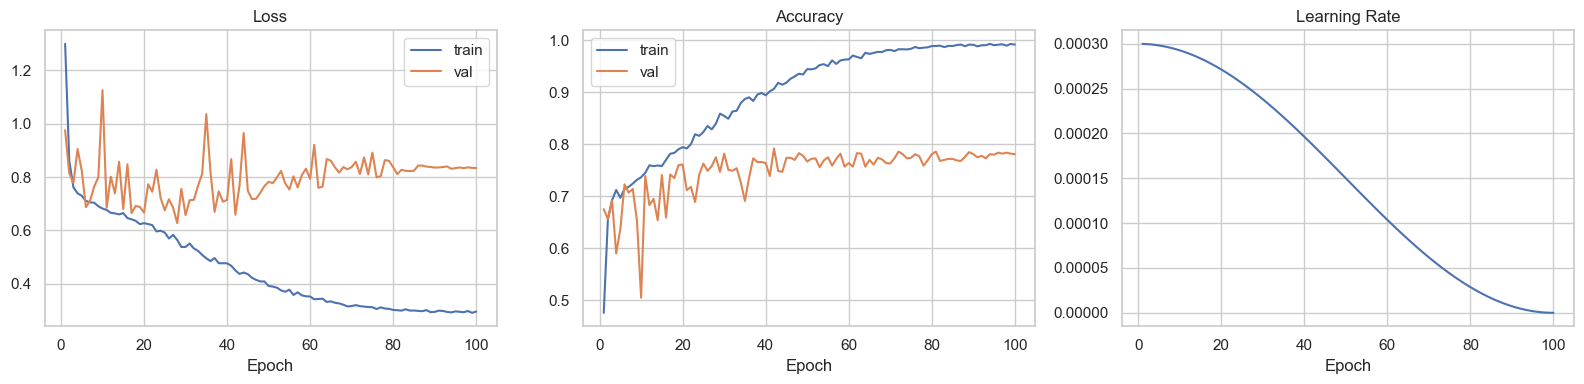

In [8]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["lr"])
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")

plt.tight_layout()

Test accuracy: 0.793
Test throughput: 6514.9 samples/s
              precision    recall  f1-score   support

       16QAM       0.68      0.73      0.71       168
       64QAM       0.72      0.67      0.69       166
        8PSK       0.65      0.81      0.72       170
        BPSK       0.99      0.97      0.98       160
        PAM4       1.00      0.99      0.99       163
        QPSK       0.78      0.60      0.68       173

    accuracy                           0.79      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.79      0.79      1000



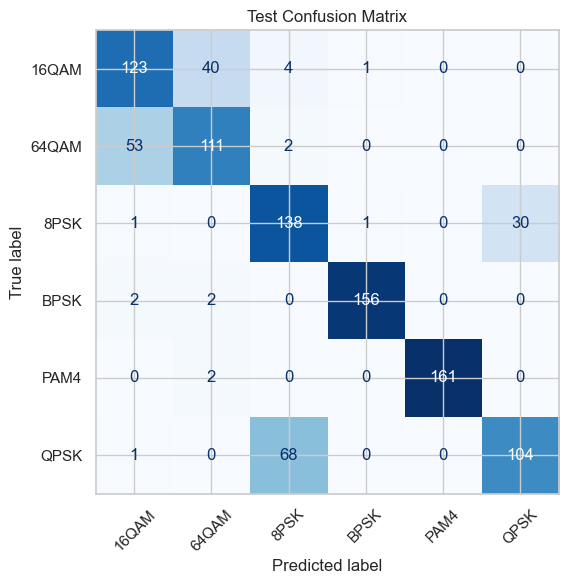

In [9]:
model.eval()
all_preds = []
all_targets = []
test_start = time.perf_counter()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if use_cuda:
            X_batch = X_batch.pin_memory().to(device, non_blocking=True)
            y_batch = y_batch.pin_memory().to(device, non_blocking=True)
        else:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

        with autocast(device_type=device.type, enabled=use_cuda):
            logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.cpu().numpy())

test_elapsed = time.perf_counter() - test_start
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)
test_acc = (y_pred == y_true).mean()

print(f"Test accuracy: {test_acc:.3f}")
print(f"Test throughput: {len(y_true) / test_elapsed:.1f} samples/s")
print(classification_report(y_true, y_pred, target_names=class_names, labels=np.arange(len(class_names)), zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()

In [10]:
runtime_stats = {
    "device": str(device),
    "total_training_time_sec": total_training_time,
    "avg_train_epoch_time_sec": float(np.mean(history["train_time"])),
    "avg_val_epoch_time_sec": float(np.mean(history["val_time"])),
    "avg_train_samples_per_sec": float(np.mean(history["train_sps"])),
    "avg_val_samples_per_sec": float(np.mean(history["val_sps"])),
    "test_samples_per_sec": float(len(y_true) / test_elapsed),
    "best_epoch": best_epoch,
    "best_val_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "checkpoint_path": str(CHECKPOINT_PATH.resolve()),
}

if use_cuda:
    runtime_stats["gpu_name"] = torch.cuda.get_device_name(0)
    runtime_stats["max_memory_allocated_mb"] = torch.cuda.max_memory_allocated() / 1024**2
    runtime_stats["max_memory_reserved_mb"] = torch.cuda.max_memory_reserved() / 1024**2

runtime_stats

{'device': 'cuda',
 'total_training_time_sec': 54.56800122000004,
 'avg_train_epoch_time_sec': 0.5161930140399726,
 'avg_val_epoch_time_sec': 0.028020624449954994,
 'avg_train_samples_per_sec': 15645.57892695571,
 'avg_val_samples_per_sec': 37474.36556381774,
 'test_samples_per_sec': 6514.851685865858,
 'best_epoch': 42,
 'best_val_accuracy': 0.792,
 'test_accuracy': 0.793,
 'checkpoint_path': '/home/klukasdh/Projects/DLSignalClassifier/phase_equivariant_cnn_signal_classifier.pt',
 'gpu_name': 'NVIDIA GeForce RTX 5090',
 'max_memory_allocated_mb': 665.9775390625,
 'max_memory_reserved_mb': 792.0}

## Notes On Why This Should Beat The Baseline

Relative to the plain real-valued CNN, this notebook makes a few changes that should help on your dataset:
- the complex stem removes sensitivity to arbitrary global phase without forcing that invariance at the raw input,
- the invariant transition keeps local phase-change information instead of discarding everything except magnitude,
- per-example RMS normalization reduces avoidable amplitude variation,
- training-time phase-ramp augmentation improves robustness to the phase and frequency nuisances already present in the generator,
- AdamW plus cosine decay and label smoothing are usually more stable than plain Adam for this kind of small classifier.

If this still underperforms, the first things to try are: widen the complex stem, shorten the synthetic frequency-ramp augmentation, or compare against a stronger real-valued baseline trained with the same augmentation and optimizer.